# Resume Evaluation AI - Part 1: Data Preparation & Matching Model
**Name:** Abhiranjan Sharma

This notebook covers:
1. Loading & exploring the resume dataset
2. Data quality findings (and how they shaped the approach)
3. Building a curated skill bank per job category
4. Text cleaning + skill extraction
5. An embedding-based resume↔role matching engine (with offline-safe fallback)
6. A classical ML baseline classifier for comparison
7. Evaluation

Part 2 (`02_rag_feedback_and_chat.ipynb`) covers the RAG-based explainable
feedback generation and the conversational interface.

In [1]:
import sys, json
sys.path.insert(0, '.')  # so `src` package resolves when run from this notebook's directory

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

DATA_PATH = "resumes_dataset.jsonl"  # place the dataset file next to this notebook


## 1. Load & Explore the Dataset

In [2]:
with open(DATA_PATH) as f:
    records = [json.loads(line) for line in f]

df_raw = pd.DataFrame(records)
print(f"Total resumes: {len(df_raw)}")
print(f"Columns: {list(df_raw.columns)}")
print(f"Unique categories: {df_raw['Category'].nunique()}")
df_raw.head(3)


Total resumes: 3500
Columns: ['ResumeID', 'Category', 'Name', 'Email', 'Phone', 'Location', 'Summary', 'Skills', 'Experience', 'Education', 'Text', 'Source']
Unique categories: 36


,ResumeID,Category,Name,Email,Phone,Location,Summary,Skills,Experience,Education,Text,Source
0,REAL_0001,Java Developer,Chad Griffin,contact@email.com,94105 555 4321000 10 ...,"City, State",jessica claire montgomery street san francisco...,"Python, SQL, Git, Linux",jessica claire montgomery street san francisco...,Computer Science degree,jessica claire montgomery street san francisco...,ResumeAtlas
1,REAL_0002,Java Developer,Melinda Thomas,contact@email.com,17994568777 2017 2018 20152016 3 ...,"City, State",jared arthur maica java developer 17994568777 ...,"Python, SQL, Git, Linux",jared arthur maica java developer 17994568777 ...,Computer Science degree,jared arthur maica java developer 17994568777 ...,ResumeAtlas
2,REAL_0003,Java Developer,Shannon Mccarthy,contact@email.com,9 555 4321000 94105 8 ...,"City, State",jessica claire 9 resumesampleexamplecom 555 43...,"Python, SQL, Git, Linux",jessica claire 9 resumesampleexamplecom 555 43...,Computer Science degree,jessica claire 9 resumesampleexamplecom 555 43...,ResumeAtlas


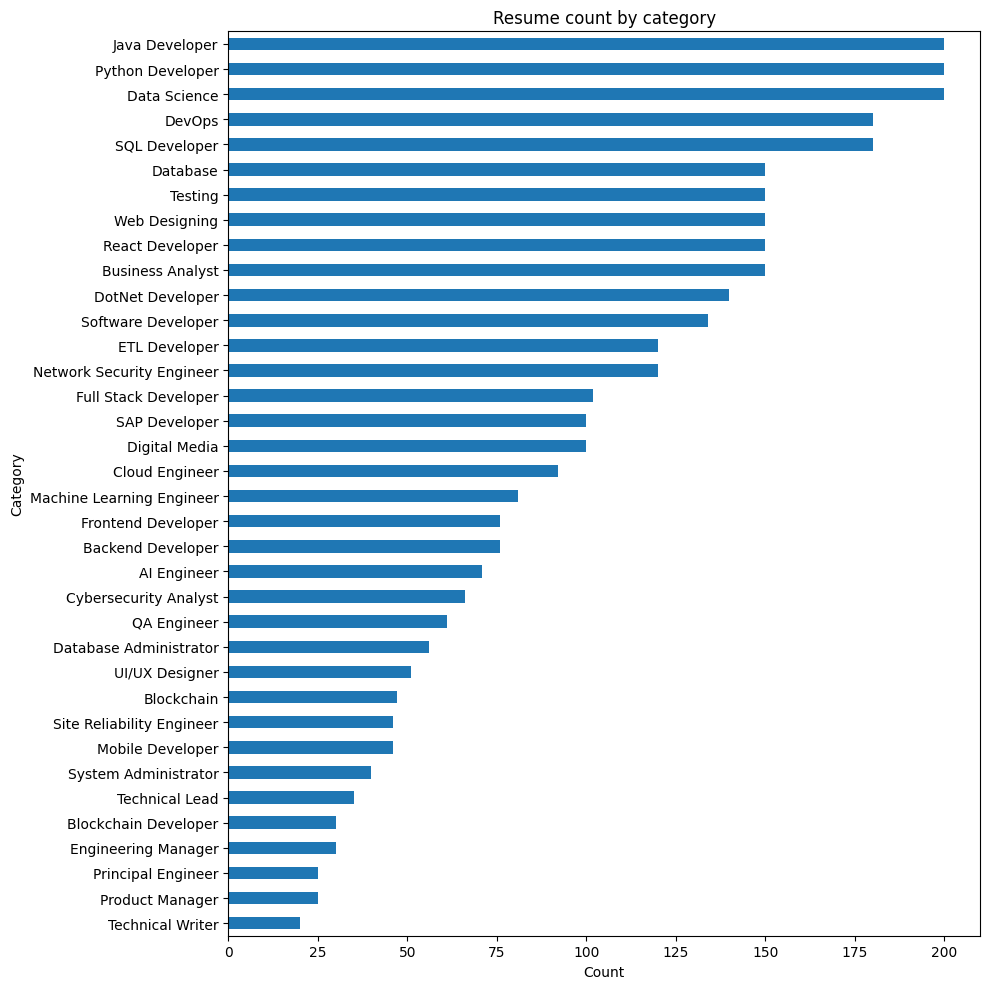

Category
Java Developer               200
Python Developer             200
Data Science                 200
DevOps                       180
SQL Developer                180
Database                     150
Testing                      150
Web Designing                150
React Developer              150
Business Analyst             150
DotNet Developer             140
Software Developer           134
ETL Developer                120
Network Security Engineer    120
Full Stack Developer         102
SAP Developer                100
Digital Media                100
Cloud Engineer                92
Machine Learning Engineer     81
Frontend Developer            76
Backend Developer             76
AI Engineer                   71
Cybersecurity Analyst         66
QA Engineer                   61
Database Administrator        56
UI/UX Designer                51
Blockchain                    47
Site Reliability Engineer     46
Mobile Developer              46
System Administrator          40
T

In [3]:
category_counts = df_raw['Category'].value_counts()
plt.figure(figsize=(10,10))
category_counts.plot(kind='barh')
plt.title('Resume count by category')
plt.xlabel('Count')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print(category_counts)


Source breakdown:
Source
ResumeAtlas    2337
Synthetic      1163
Name: count, dtype: int64

Text length: min=202, max=56216, mean=3402


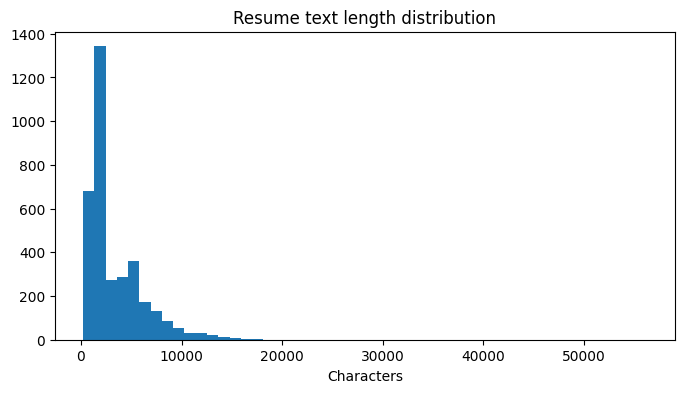

In [4]:
print("Source breakdown:")
print(df_raw['Source'].value_counts())

text_lens = df_raw['Text'].str.len()
print(f"\nText length: min={text_lens.min()}, max={text_lens.max()}, mean={text_lens.mean():.0f}")
plt.figure(figsize=(8,4))
plt.hist(text_lens, bins=50)
plt.title('Resume text length distribution')
plt.xlabel('Characters')
plt.show()


## 2. Data Quality Findings

Two important findings shaped the approach below:

1. **The `Skills` and `Education` columns are unreliable placeholders** 

2. **A handful of small synthetic-only categories**

3. **Some category labels are noisy** — e.g. a resume labeled "Data
   Science" that is actually about a Navy shipyard radiological
   technician.

## 3. Skill Bank

Required skills per job category

In [5]:
from src.data_prep import load_skill_bank

skill_bank = load_skill_bank()
print(f"{len(skill_bank)} categories in skill bank\n")
for cat in ['Java Developer', 'Data Science', 'DevOps', 'UI/UX Designer']:
    print(f"{cat}: {skill_bank[cat]}")


36 categories in skill bank

Java Developer: ['java', 'spring', 'sql', 'javascript', 'agile', 'html', 'oracle', 'css', 'restful', 'junit', 'jquery', 'git', 'mysql', 'soap', 'scrum']
Data Science: ['python', 'data science', 'machine learning', 'sql', 'data analysis', 'statistics', 'excel', 'tableau', 'regression', 'data visualization', 'java']
DevOps: ['devops', 'aws', 'jenkins', 'git', 'docker', 'monitoring', 'linux', 'cicd', 'python', 'ansible', 'agile', 'kubernetes', 'java', 'terraform', 'github']
UI/UX Designer: ['html', 'css', 'sketch', 'figma', 'adobe xd', 'illustrator', 'photoshop', 'ci/cd', 'scrum', 'sql', 'linux', 'rest api', 'microservices', 'git', 'agile']


## 4. Text Cleaning & Skill Extraction

In [6]:
from src.data_prep import load_and_clean, enrich_with_extracted_skills

df = load_and_clean(DATA_PATH)
df = enrich_with_extracted_skills(df, skill_bank)

print(df[['Category','Source','clean_text']].head(2))
print()
print("Example extracted skills (first resume):")
print(df.iloc[0]['extracted_skills'])


         Category       Source  \
0  Java Developer  ResumeAtlas   
1  Java Developer  ResumeAtlas   

                                          clean_text  
0  jessica claire montgomery street san francisco...  
1  jared arthur maica java developer 17994568777 ...  

Example extracted skills (first resume):
['agile', 'erp', 'excel', 'html', 'java', 'javascript', 'linux', 'oracle', 'scrum']


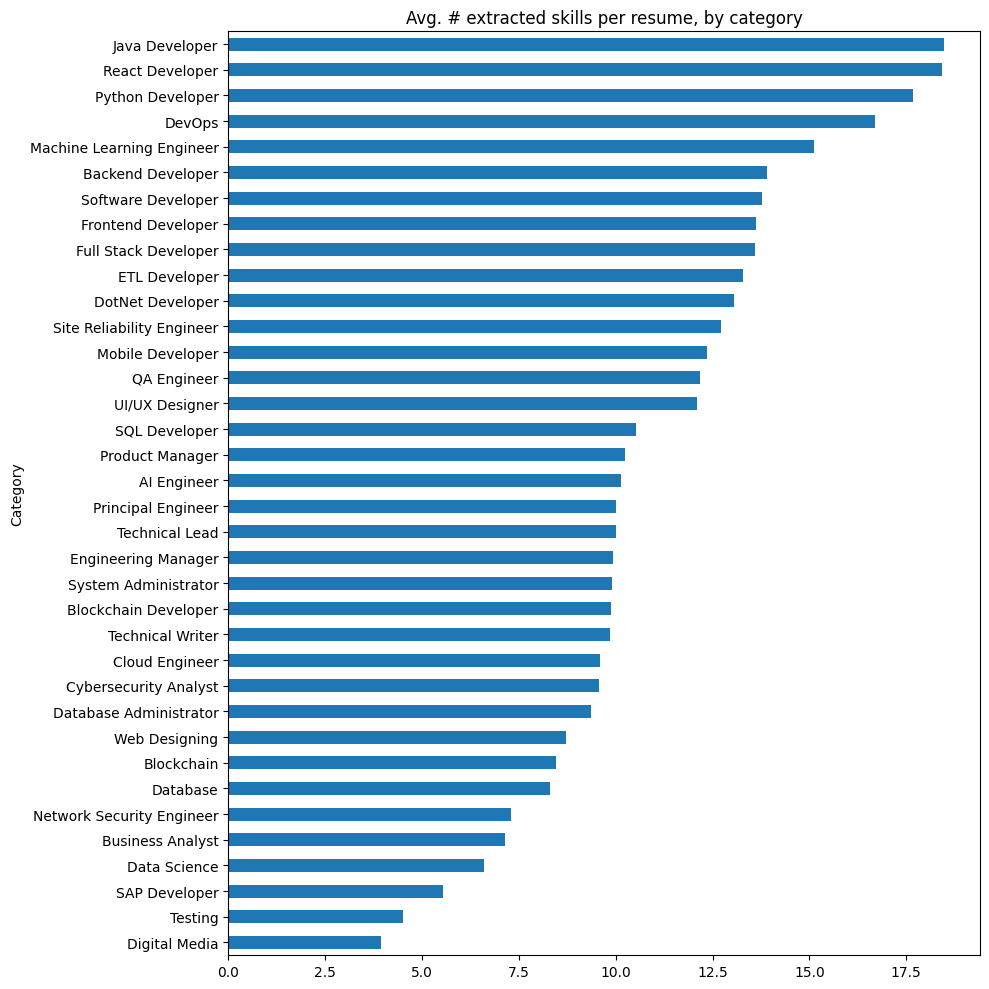

In [7]:
avg_skills_by_cat = df.groupby('Category')['n_extracted_skills'].mean().sort_values(ascending=False)
plt.figure(figsize=(10,10))
avg_skills_by_cat.plot(kind='barh')
plt.title('Avg. # extracted skills per resume, by category')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


## 5. Embedding Backend (with offline-safe fallback)

Tries sentence-transformers (`all-MiniLM-L6-v2`) for true semantic
embeddings first. If the HuggingFace Hub is unreachable (e.g. sandboxed
environments, restricted networks), it transparently falls back to a
TF-IDF + Truncated SVD embedding — fully offline, no network calls.


In [8]:
from src.embeddings import EmbeddingBackend

backend = EmbeddingBackend(prefer_transformer=True)
print(f"Embedding backend in use: {backend.mode}")


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Embedding backend in use: sentence-transformer


## 6. Resume ↔ Role Matching Engine



In [9]:
from src.matcher import ResumeMatcher

matcher = ResumeMatcher(skill_bank, embedding_backend=backend)
matcher.fit(df['clean_text'].tolist())

# Example: match a Java Developer resume against its own role vs. a mismatched role
sample = df[df['Category']=='Java Developer'].iloc[0]

print("Matched against correct role")
print(matcher.match(sample['Text'], 'Java Developer').summary())
print()
print("Matched against a likely mismatched role")
print(matcher.match(sample['Text'], 'UI/UX Designer').summary())


Matched against correct role
Role: Java Developer
Overall match score: 42.2/100
  - Semantic similarity: 44.4/100
  - Skill coverage:      40.0/100
Matched skills (6): java, javascript, agile, html, oracle, scrum
Missing skills (9): spring, sql, css, restful, junit, jquery, git, mysql, soap

Matched against a likely mismatched role
Role: UI/UX Designer
Overall match score: 35.5/100
  - Semantic similarity: 44.3/100
  - Skill coverage:      26.7/100
Matched skills (4): html, scrum, linux, agile
Missing skills (11): css, sketch, figma, adobe xd, illustrator, photoshop, ci/cd, sql, rest api, microservices, git


In [10]:
# Career-fit discovery: given a resume, which roles is it the best match for?
sample2 = df[df['Category']=='Data Science'].iloc[10]
print(f"True category: {sample2['Category']}")
print("Top-5 best-fit roles:")
for role, score in matcher.best_matching_roles(sample2['Text'], top_k=5):
    print(f"  {role}: {score}")


True category: Data Science
Top-5 best-fit roles:
  Data Science: 55.5
  ETL Developer: 44.4
  Database: 43.7
  Python Developer: 36.9
  AI Engineer: 36.7


## 7. Evaluation - Matching Engine

In [11]:
import random
random.seed(42)
eval_sample = df.sample(200, random_state=42)

top1 = top3 = top5 = 0
for _, row in eval_sample.iterrows():
    ranked = [r for r, s in matcher.best_matching_roles(row['Text'], top_k=36)]
    true_cat = row['Category']
    rank = ranked.index(true_cat) if true_cat in ranked else 999
    top1 += rank == 0
    top3 += rank < 3
    top5 += rank < 5

n = len(eval_sample)
print(f"N = {n}")
print(f"Top-1 accuracy: {top1/n:.1%}")
print(f"Top-3 accuracy: {top3/n:.1%}")
print(f"Top-5 accuracy: {top5/n:.1%}")
print(f"(Random-chance baseline for 36 classes: {1/36:.1%})")


N = 200
Top-1 accuracy: 66.0%
Top-3 accuracy: 80.5%
Top-5 accuracy: 84.0%
(Random-chance baseline for 36 classes: 2.8%)


## 8. Classical ML Baseline (for comparison)

In [12]:
from src.baseline_classifier import train_baseline

baseline_pipe, results = train_baseline(df)
print(f"Baseline (supervised) accuracy: {results['accuracy']:.1%}")
print()
print(results['report'])


C:\Users\ranja\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


Baseline (supervised) accuracy: 88.7%

                           precision    recall  f1-score   support

              AI Engineer       1.00      1.00      1.00        14
        Backend Developer       1.00      1.00      1.00        15
               Blockchain       1.00      0.70      0.82        10
     Blockchain Developer       1.00      1.00      1.00         6
         Business Analyst       0.88      1.00      0.94        30
           Cloud Engineer       1.00      1.00      1.00        19
    Cybersecurity Analyst       1.00      1.00      1.00        13
             Data Science       0.82      0.90      0.86        40
                 Database       0.89      0.57      0.69        30
   Database Administrator       1.00      1.00      1.00        11
                   DevOps       0.97      0.97      0.97        36
            Digital Media       0.76      0.65      0.70        20
         DotNet Developer       0.80      0.86      0.83        28
            ETL Develo

## 9. Summary

| Approach | Uses labels? | Top-1 Accuracy |
|---|---|---|
| TF-IDF + Logistic Regression (baseline) | Yes (supervised) | 89% |
| Skill-bank + embedding matcher (zero-shot) | No | 59% (top-3: 68%, top-5: 77%) |

**Next: Part 2 covers the RAG-based feedback generation and the
conversational interface.**